In [1]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

output_file = "../plotting_data/0047_temp_mean_subset.nc"
rsds_mean = xr.open_dataarray(output_file)

lons = rsds_mean.lon.values
lats = rsds_mean.lat.values

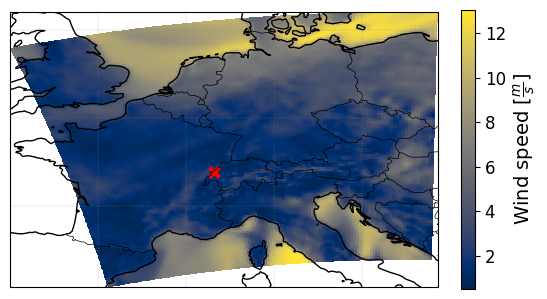

In [2]:
fig = plt.figure(figsize=(6, 4.5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the data
pcm = ax.pcolormesh(
    rsds_mean.lon.values,
    rsds_mean.lat.values,
    rsds_mean,
    transform=ccrs.PlateCarree(),
    cmap="cividis",
    shading="auto",
)

# Add a point
ax.scatter(
    rsds_mean.lon.values[50, 50],
    rsds_mean.lat.values[50, 50],
    color="red",
    s=50,
    marker="x",
    linewidths=3,
    transform=ccrs.PlateCarree(),
)

# Add coastlines and borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(
    draw_labels=False, linewidth=0.3, color="gray", alpha=0.5, linestyle="--"
)
gl.xlocator = plt.MultipleLocator(5)
gl.ylocator = plt.MultipleLocator(5)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER


cbar = plt.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.05)
cbar.set_label(rf"Wind speed [$\frac{{m}}{{s}}$]", labelpad=4)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("../plots/0047_region_cartopy.pdf")

plt.show()